#  Smartphone Usage <hr style="border:2.5px solid #126782"></hr>

<b>Griffin Vann L. Dymosco
<br>Computer Engineering Technology

In [33]:
# imports and packages
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower

# Full Dataset

In [34]:
# load dataset
df = pd.read_csv(r"csv\Smartphone_Usage_Productivity_Dataset_50000.csv",
                 delimiter=",")
df_sample = df[0:50]

df_sample

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9
5,U6,32,Female,Student,Android,10.9,4.2,9,6.3,7,34,5,3.6
6,U7,26,Male,Student,iOS,5.6,6.1,8,6.7,3,5,3,2.9
7,U8,24,Male,Freelancer,iOS,8.5,1.9,4,7.8,3,6,6,12.8
8,U9,52,Female,Business Owner,Android,9.4,2.5,3,6.4,4,17,3,3.1
9,U10,23,Female,Student,iOS,2.8,1.1,1,4.5,2,7,0,2.7


In [35]:
# summary of dataframe
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    50 non-null     object 
 1   Age                        50 non-null     int64  
 2   Gender                     50 non-null     object 
 3   Occupation                 50 non-null     object 
 4   Device_Type                50 non-null     object 
 5   Daily_Phone_Hours          50 non-null     float64
 6   Social_Media_Hours         50 non-null     float64
 7   Work_Productivity_Score    50 non-null     int64  
 8   Sleep_Hours                50 non-null     float64
 9   Stress_Level               50 non-null     int64  
 10  App_Usage_Count            50 non-null     int64  
 11  Caffeine_Intake_Cups       50 non-null     int64  
 12  Weekend_Screen_Time_Hours  50 non-null     float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.2

In [36]:
# summary of statistics
df_sample.describe()

,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000,50.000000
mean,36.280000,6.418000,4.158000,5.280000,6.366000,5.560000,33.20000,2.860000,6.952000
std,12.480254,3.662757,2.219035,2.828716,1.480983,3.124361,16.54678,2.203985,3.298066
min,18.000000,1.000000,0.500000,1.000000,4.300000,1.000000,5.00000,0.000000,2.100000
25%,25.000000,3.325000,2.075000,3.000000,5.100000,3.000000,19.50000,1.000000,4.125000
50%,34.500000,5.800000,4.250000,5.000000,6.150000,5.000000,36.00000,3.000000,6.600000
75%,45.750000,9.675000,6.175000,8.000000,7.775000,8.000000,45.75000,5.000000,9.200000
max,59.000000,12.000000,7.800000,10.000000,9.000000,10.000000,59.00000,6.000000,13.300000


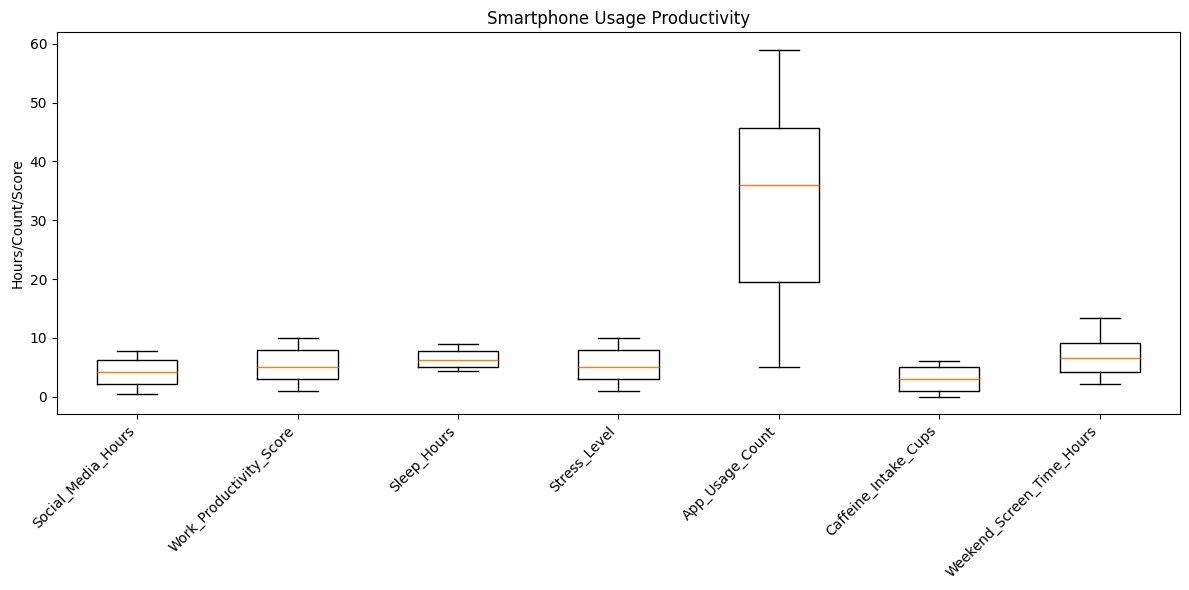

In [37]:
selected_cols = [
    'Social_Media_Hours', 'Work_Productivity_Score', 'Sleep_Hours', 
    'Stress_Level', 'App_Usage_Count', 'Caffeine_Intake_Cups', 
    'Weekend_Screen_Time_Hours'
]

plt.figure(figsize=(12, 6))
plt.boxplot(df_sample[selected_cols], tick_labels=selected_cols)
plt.title('Smartphone Usage Productivity')
plt.ylabel('Hours/Count/Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2-Sample t-Test

## Social Media Hours and Sleep Hours

In [38]:
df_sample[['Social_Media_Hours','Sleep_Hours']].describe()

,Social_Media_Hours,Sleep_Hours
count,50.000000,50.000000
mean,4.158000,6.366000
std,2.219035,1.480983
min,0.500000,4.300000
25%,2.075000,5.100000
50%,4.250000,6.150000
75%,6.175000,7.775000
max,7.800000,9.000000


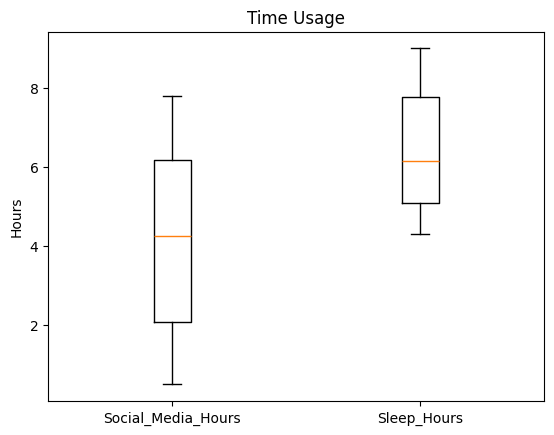

In [39]:
#check for outliers
plt.boxplot(df_sample[['Social_Media_Hours','Sleep_Hours']], tick_labels=['Social_Media_Hours','Sleep_Hours'])
plt.title('Time Usage')
plt.ylabel('Hours')
plt.show()

In [40]:
# shapiro-wilk normality test
print('Social Media Hours:')
w_stat, p_value = stats.shapiro(df_sample['Social_Media_Hours'])

print(f'w_stat: {w_stat:.4f}')
print(f'P-value: {p_value:.4f}')

#verdict
alpha = 0.05
if p_value < alpha:
    print('Non-normal data')
else:
    print('Normal Data')

print('\nSleep_Hours:')
w_stat, p_value = stats.shapiro(df_sample['Sleep_Hours'])

print(f'w_stat: {w_stat:.4f}')
print(f'P-value: {p_value:.4f}')

#verdict
alpha = 0.05
if p_value < alpha:
    print('Non-normal data')
else:
    print('Normal Data')


Social Media Hours:
w_stat: 0.9320
P-value: 0.0066
Non-normal data

Sleep_Hours:
w_stat: 0.9328
P-value: 0.0070
Non-normal data


In [43]:
"""
F-Test for equality of variances
--------------------------------
Ho: var_social_media = var_sleep
Ha: var_social_media != var_sleep
"""

var_sm = df_sample['Social_Media_Hours'].var(ddof=1)
var_sleep = df_sample['Sleep_Hours'].var(ddof=1)

# F-statistic
if var_sm > var_sleep:
    f_stat = var_sm / var_sleep
else:
    f_stat = var_sleep / var_sm

print(f'f_stat = {f_stat:.4f}')

# Degrees of Freedom
dof_sm = df_sample['Social_Media_Hours'].count() - 1
dof_sleep = df_sample['Sleep_Hours'].count() - 1

# probability value (multiplied by 2 for a two-tailed F-test)
p_value = (1 - stats.f.cdf(f_stat, dof_sm, dof_sleep)) * 2
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Unequal variances")
else:
    # fail to reject null hypothesis
    print("Equal variances")

f_stat = 2.2451
p_value = 0.0054
Unequal variances


In [44]:
"""
2-Sample T-Test for Independent Samples
----------------------------------------
Ho: Social Media Hours == Sleep Hours
Ha: Social Media Hours != Sleep Hours
"""

# equal_var=False because the F-test showed unequal variances
t_stat, p_value = stats.ttest_ind(
    df_sample['Social_Media_Hours'],
    df_sample['Sleep_Hours'],
    alternative='two-sided',
    equal_var=False 
)

print(f't_stat = {t_stat:.4f}')
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("There is a significant difference between Social Media Hours and Sleep Hours.")
else:
    # fail to reject null hypothesis
    print("There is no significant difference between Social Media Hours and Sleep Hours.")

t_stat = -5.8522
p_value = 0.0000
There is a significant difference between Social Media Hours and Sleep Hours.
